In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import os
import torchaudio

from sklearn.model_selection import train_test_split
from torchvision import models

In [2]:
import random

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
def load_indifake_paths(root_dir):

    audio_paths = []
    labels = []

    for root, dirs, files in os.walk(root_dir):

        folder = root.lower()

        if "bonafide" in folder:
            label = 0
        elif "deepfake" in folder:
            label = 1
        else:
            continue

        for file in files:

            if file.lower().endswith((".wav", ".flac", ".mp3")):
                full_path = os.path.join(root, file)
                audio_paths.append(full_path)
                labels.append(label)

    return audio_paths, labels

In [4]:
root_dir = "IndieFake"

X, y = load_indifake_paths(root_dir)

print("Total samples:", len(X))

Total samples: 19615


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 15692
Test samples: 3923


c:\Users\Ezekiel\anaconda3\envs\ml_dl\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


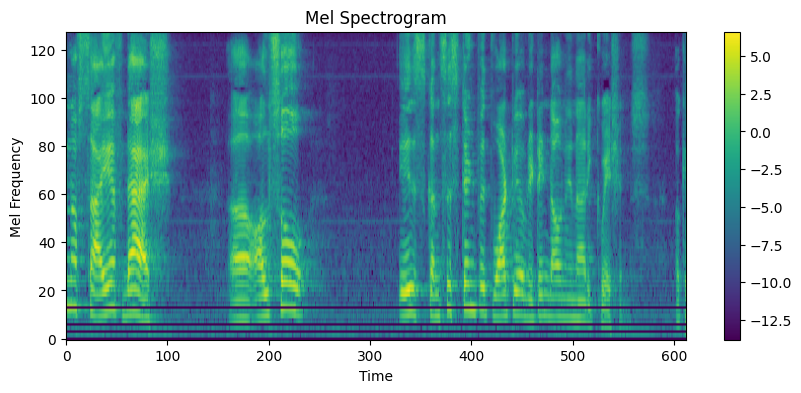

In [6]:
sample_path = X_train[0]

waveform, sr = torchaudio.load(sample_path)

# Mel spectrogram
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=128
)

mel = mel_transform(waveform)
mel = torch.log(mel + 1e-6)

plt.figure(figsize=(10, 4))
plt.imshow(mel[0].numpy(), aspect='auto', origin='lower')
plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.colorbar()
plt.show()

In [7]:
class IndieFakeDataset(Dataset):

    def __init__(self, paths, labels, min_length=6, sample_rate=16000):

        self.paths = paths
        self.labels = labels
        self.sample_rate = sample_rate
        self.min_samples = min_length * sample_rate

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000,
            n_mels=128
        )

        # augmentation for minority class
        self.time_mask = torchaudio.transforms.TimeMasking(time_mask_param=30)
        self.freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            waveform, sr = torchaudio.load(path)
        except:
            waveform = torch.zeros(1, self.min_samples)
            sr = self.sample_rate

        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
            
        # Pad or truncate to 5 seconds
        if waveform.shape[1] < self.min_samples:
            pad = self.min_samples - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad))
        else:
            waveform = waveform[:, :self.min_samples]
            
        mel = self.mel_transform(waveform)
        mel = torch.log(mel + 1e-6)
        mel = (mel - mel.mean()) / (mel.std() + 1e-9)

        label = self.labels[idx]

        if label == 0:
            mel = self.time_mask(mel)
            mel = self.freq_mask(mel)

        label = torch.tensor(label).long()

        return mel, torch.tensor(label).long()

In [8]:
def collate_fn(batch):
    mels, labels = zip(*batch)
    mels = torch.stack(mels)
    labels = torch.tensor(labels)
    return mels, labels

In [9]:
train_dataset = IndieFakeDataset(X_train, y_train)
test_dataset = IndieFakeDataset(X_test, y_test)

In [10]:
batch_size = 32

In [11]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

Laoding the model

In [12]:
model = models.efficientnet_b0(pretrained=True)

# Save old weights
old_weights = model.features[0][0].weight

# Replace first conv layer (3 → 1 channel)
model.features[0][0] = nn.Conv2d(
    1, 32, kernel_size=3, stride=2, padding=1, bias=False
)

model.features[0][0].weight.data = old_weights.mean(dim=1, keepdim=True)

c:\Users\Ezekiel\anaconda3\envs\ml_dl\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Ezekiel\anaconda3\envs\ml_dl\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
# freeze the conv layers
for param in model.parameters():
    param.requires_grad = False
    
# unfreeze last 3 layers
for i in [5, 6, 7]:
    for param in model.features[i].parameters():
        param.requires_grad = True

In [14]:
for param in model.classifier.parameters():
    param.requires_grad = True

Replacing the classifier

In [15]:
model.classifier = nn.Sequential(
    nn.Linear(1280, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(128, 2)
)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

class imbalance handling

In [17]:
class_counts = np.bincount(y_train)
weights = 1. / class_counts
weights = torch.tensor(weights, dtype=torch.float32).to(device)

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.classifier.parameters(), lr=0.001)

scheduler

In [19]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [20]:
def train_epoch(loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()

        total += y.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [21]:
def evaluate(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()

            total += y.size(0)

    return correct / total

In [22]:
best_acc = 0
patience = 3
counter = 0
best_model_weights = None

In [23]:
epochs = 10

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    train_loss, train_acc = train_epoch(train_loader)

    test_acc = evaluate(test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Dev Accuracy: {test_acc:.4f}")

    print("*"*50) 
    
    # Early Stopping
    if test_acc > best_acc:
        best_acc = test_acc
        counter = 0

        best_model_weights = model.state_dict().copy()
    else:
        counter += 1

        if counter >= patience:
            break

C:\Users\Ezekiel\AppData\Local\Temp\ipykernel_8668\2579222203.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return mel, torch.tensor(label).long()



Epoch 1/10
Train Loss: 0.1547
Train Accuracy: 0.9380
Dev Accuracy: 0.9748
**************************************************

Epoch 2/10
Train Loss: 0.0994
Train Accuracy: 0.9604
Dev Accuracy: 0.9778
**************************************************

Epoch 3/10
Train Loss: 0.0909
Train Accuracy: 0.9658
Dev Accuracy: 0.9806
**************************************************

Epoch 4/10
Train Loss: 0.0842
Train Accuracy: 0.9690
Dev Accuracy: 0.9827
**************************************************

Epoch 5/10
Train Loss: 0.0754
Train Accuracy: 0.9726
Dev Accuracy: 0.9743
**************************************************

Epoch 6/10
Train Loss: 0.0689
Train Accuracy: 0.9724
Dev Accuracy: 0.9847
**************************************************

Epoch 7/10
Train Loss: 0.0619
Train Accuracy: 0.9780
Dev Accuracy: 0.9824
**************************************************

Epoch 8/10
Train Loss: 0.0642
Train Accuracy: 0.9771
Dev Accuracy: 0.9883
*******************************************

PLot accuracy

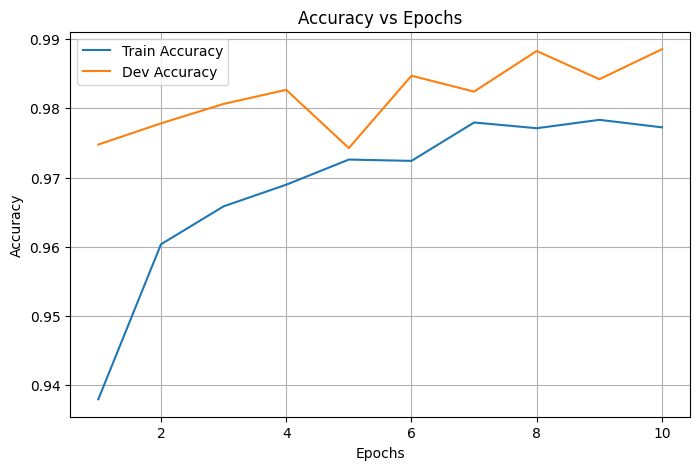

In [24]:
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, epochs+1), test_accuracies, label="Dev Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Epochs")  

plt.legend()
plt.grid(True)

plt.show()

PLot Loss

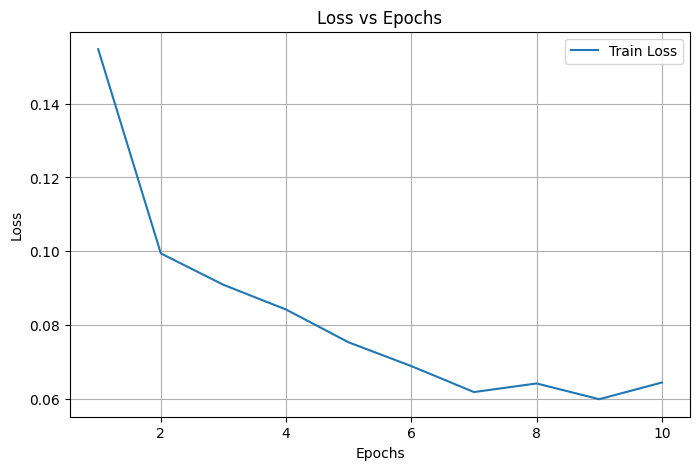

In [25]:
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs+1), train_losses, label="Train Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Loss vs Epochs")

plt.legend()
plt.grid(True)

plt.show()

C:\Users\Ezekiel\AppData\Local\Temp\ipykernel_8668\2579222203.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return mel, torch.tensor(label).long()


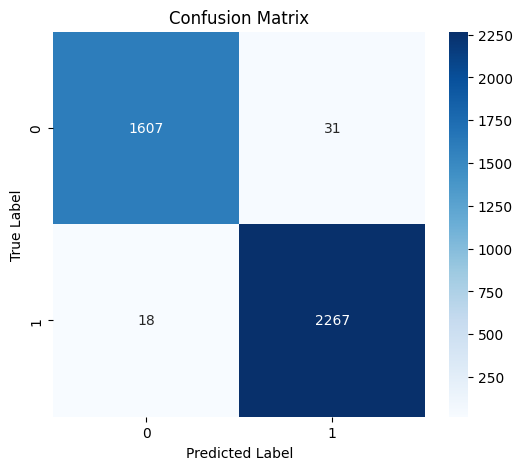

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        outputs = model(x)

        preds = torch.argmax(outputs, dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1638
           1       0.99      0.99      0.99      2285

    accuracy                           0.99      3923
   macro avg       0.99      0.99      0.99      3923
weighted avg       0.99      0.99      0.99      3923



Save Model

In [28]:
import os

save_path = "saved_models/inddiefake_efficientnet_b0.pth"

os.makedirs("saved_models", exist_ok=True)

model.load_state_dict(best_model_weights)

torch.save({
    "model_state_dict": model.state_dict(),
    "model_name": "efficientnet_b0_audio",
}, save_path)

print("Saved at:", save_path)

Saved at: saved_models/inddiefake_efficientnet_b0.pth


Testing Model

In [ ]:
def preprocess(file_path):
    waveform, _ = torchaudio.load(file_path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    mel = mel_transform(waveform)
    mel = torch.log(mel + 1e-6)
    mel = (mel - mel.mean()) / (mel.std() + 1e-9)

    return mel.unsqueeze(0)

In [ ]:
def predict_audio(file_path):
    model.eval()

    try:
        mel = preprocess(file_path).to(device)
    except:
        return "Error"  

    with torch.no_grad():
        output = model(mel)
        pred = torch.argmax(output, dim=1).item()

    return "Fake" if pred == 1 else "Real"

In [46]:
unique, counts = np.unique(y_train, return_counts=True)

for u, c in zip(unique, counts):
    label = "Real" if u == 0 else "Fake"
    print(f"{label}: {c}")

Real: 6551
Fake: 9141


In [48]:
for i in range(20):
    pred = predict_audio(X_test[i])
    actual = "Fake" if y_test[i] == 1 else "Real"

    if pred == "Error":
        print(f"Skipped: {X_test[i]}")
    else:
        print(f"Pred={pred}, Actual={actual}")

Skipped: IndieFake\A\Speaker-12\Deepfakes\Speaker-12_deepfake40.wav
Pred=Real, Actual=Real
Pred=Real, Actual=Real
Pred=Real, Actual=Real
Pred=Fake, Actual=Fake
Pred=Fake, Actual=Fake
Pred=Fake, Actual=Fake
Pred=Real, Actual=Real
Pred=Real, Actual=Real
Pred=Real, Actual=Real
Pred=Real, Actual=Real
Pred=Fake, Actual=Fake
Pred=Real, Actual=Real
Pred=Fake, Actual=Real
Pred=Fake, Actual=Fake
Pred=Real, Actual=Real
Pred=Real, Actual=Real
Pred=Fake, Actual=Fake
Pred=Real, Actual=Real
Pred=Real, Actual=Real
